<a href="https://colab.research.google.com/github/emiliomercuri/EnvHydrology2026/blob/main/Aulas/Aula03-Armazenamento/Leitura_base_CABra_e_Regressa%CC%83o_Linear_Temperatura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Leitura da base CABra e Regressão Linear dos dados de Temperatura média na bacia

1. Acessar o site da plataforma Catchments Attributes for Brazil (CABra) https://thecabradataset.shinyapps.io/CABra/

2. Baixar os dados **Climate** e **Streamflow**

3. Colocar os arquivos no Google Drive

4. Compartilhar os arquivos (opção "qualquer pessoa com o link") e copiar o link

5. Fazer gráficos das variáveis hidrológicas e uma regressão linear dos dados de temperatura anual média na bacia ao longo de 30 anos.

In [ ]:
import pandas as pd
import numpy
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

## Download dos dados na máquina virtual Google


In [ ]:
# Baixa dados da base CABra
!gdown 1TaMLC6-FbfXKltZRvCmGPEGUFwm6NVG8
!gdown 10Q5W4Lj5Mi3RbEzEBf4vd3CRz5iZiFld

Downloading...
From: https://drive.google.com/uc?id=1TaMLC6-FbfXKltZRvCmGPEGUFwm6NVG8
To: /content/CABra_1_climate_ENS.txt
100% 1.47M/1.47M [00:00<00:00, 145MB/s]
Downloading...
From: https://drive.google.com/uc?id=10Q5W4Lj5Mi3RbEzEBf4vd3CRz5iZiFld
To: /content/CABra_1_streamflow.txt
100% 482k/482k [00:00<00:00, 115MB/s]


## Leitura dos dados climáticos

In [ ]:
# leitura dos dados com pandas
df_climate = pd.read_csv('CABra_1_climate_ENS.txt',sep='\s+',skiprows=13)
df_climate

,Year,Month,Day,p_ens,tmin_ens,tmax_ens,rh_ens,wnd_ens,srad_ens,et_ens,pet_pm,pet_pt,pet_hg
0,mm,°C,°C,%,m,s¯¹,MJ,m¯²,mm,mm,mm,mm,NaN
1,1980,1,1,17.744,20.745,27.849,89.784,1.068,11.593,3.928,3.139,3.652,2.700
2,1980,1,2,6.515,20.510,29.676,84.342,0.522,16.139,4.038,4.082,4.934,3.825
3,1980,1,3,4.314,21.578,30.517,84.951,0.820,17.680,4.202,4.523,5.406,4.262
4,1980,1,4,3.955,22.022,31.363,82.714,1.012,16.178,4.729,4.318,5.017,3.963
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11319,2010,12,27,9.375,22.935,29.573,85.749,1.214,15.057,4.146,3.930,4.688,3.658
11320,2010,12,28,6.888,22.896,31.206,82.553,1.165,19.261,3.709,4.957,5.922,4.759
11321,2010,12,29,4.397,23.094,31.305,82.595,1.446,19.609,4.544,5.090,6.033,4.866
11322,2010,12,30,6.692,22.873,30.114,84.971,1.329,15.503,4.686,4.080,4.818,3.779


In [ ]:
# Remove a primeira linha do dataframe
df_climate = df_climate.drop([0])
df_climate

,Year,Month,Day,p_ens,tmin_ens,tmax_ens,rh_ens,wnd_ens,srad_ens,et_ens,pet_pm,pet_pt,pet_hg
1,1980,1,1,17.744,20.745,27.849,89.784,1.068,11.593,3.928,3.139,3.652,2.700
2,1980,1,2,6.515,20.510,29.676,84.342,0.522,16.139,4.038,4.082,4.934,3.825
3,1980,1,3,4.314,21.578,30.517,84.951,0.820,17.680,4.202,4.523,5.406,4.262
4,1980,1,4,3.955,22.022,31.363,82.714,1.012,16.178,4.729,4.318,5.017,3.963
5,1980,1,5,4.798,21.741,30.880,82.440,1.134,17.508,3.945,4.597,5.379,4.256
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11319,2010,12,27,9.375,22.935,29.573,85.749,1.214,15.057,4.146,3.930,4.688,3.658
11320,2010,12,28,6.888,22.896,31.206,82.553,1.165,19.261,3.709,4.957,5.922,4.759
11321,2010,12,29,4.397,23.094,31.305,82.595,1.446,19.609,4.544,5.090,6.033,4.866
11322,2010,12,30,6.692,22.873,30.114,84.971,1.329,15.503,4.686,4.080,4.818,3.779


In [ ]:
df_climate.columns

Index(['Year', 'Month', 'Day', 'p_ens', 'tmin_ens', 'tmax_ens', 'rh_ens',
       'wnd_ens', 'srad_ens', 'et_ens', 'pet_pm', 'pet_pt', 'pet_hg'],
      dtype='object')

In [ ]:
ano = df_climate['Year'].values
mes = df_climate['Month'].values
dia = df_climate['Day'].values

In [ ]:
data = []
for i in range(len(df_climate)):
    data.append(ano[i] + '-' + mes[i] + '-' + dia[i])
#data

In [ ]:
lista = []
for i in range(len(df_climate)):
    lista.append(datetime.strptime(data[i], '%Y-%m-%d'))

In [ ]:
df_climate['data'] = lista
df_climate

,Year,Month,Day,p_ens,tmin_ens,tmax_ens,rh_ens,wnd_ens,srad_ens,et_ens,pet_pm,pet_pt,pet_hg,data
1,1980,1,1,17.744,20.745,27.849,89.784,1.068,11.593,3.928,3.139,3.652,2.700,1980-01-01
2,1980,1,2,6.515,20.510,29.676,84.342,0.522,16.139,4.038,4.082,4.934,3.825,1980-01-02
3,1980,1,3,4.314,21.578,30.517,84.951,0.820,17.680,4.202,4.523,5.406,4.262,1980-01-03
4,1980,1,4,3.955,22.022,31.363,82.714,1.012,16.178,4.729,4.318,5.017,3.963,1980-01-04
5,1980,1,5,4.798,21.741,30.880,82.440,1.134,17.508,3.945,4.597,5.379,4.256,1980-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11319,2010,12,27,9.375,22.935,29.573,85.749,1.214,15.057,4.146,3.930,4.688,3.658,2010-12-27
11320,2010,12,28,6.888,22.896,31.206,82.553,1.165,19.261,3.709,4.957,5.922,4.759,2010-12-28
11321,2010,12,29,4.397,23.094,31.305,82.595,1.446,19.609,4.544,5.090,6.033,4.866,2010-12-29
11322,2010,12,30,6.692,22.873,30.114,84.971,1.329,15.503,4.686,4.080,4.818,3.779,2010-12-30


In [ ]:
df_climate = df_climate.set_index('data')
df_climate

,Year,Month,Day,p_ens,tmin_ens,tmax_ens,rh_ens,wnd_ens,srad_ens,et_ens,pet_pm,pet_pt,pet_hg
data,,,,,,,,,,,,,
1980-01-01,1980,1,1,17.744,20.745,27.849,89.784,1.068,11.593,3.928,3.139,3.652,2.700
1980-01-02,1980,1,2,6.515,20.510,29.676,84.342,0.522,16.139,4.038,4.082,4.934,3.825
1980-01-03,1980,1,3,4.314,21.578,30.517,84.951,0.820,17.680,4.202,4.523,5.406,4.262
1980-01-04,1980,1,4,3.955,22.022,31.363,82.714,1.012,16.178,4.729,4.318,5.017,3.963
1980-01-05,1980,1,5,4.798,21.741,30.880,82.440,1.134,17.508,3.945,4.597,5.379,4.256
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-12-27,2010,12,27,9.375,22.935,29.573,85.749,1.214,15.057,4.146,3.930,4.688,3.658
2010-12-28,2010,12,28,6.888,22.896,31.206,82.553,1.165,19.261,3.709,4.957,5.922,4.759
2010-12-29,2010,12,29,4.397,23.094,31.305,82.595,1.446,19.609,4.544,5.090,6.033,4.866


In [ ]:
print(df_climate.dtypes)

Year         object
Month        object
Day          object
p_ens        object
tmin_ens     object
tmax_ens     object
rh_ens       object
wnd_ens      object
srad_ens     object
et_ens       object
pet_pm       object
pet_pt       object
pet_hg      float64
dtype: object


In [ ]:
# Change column A's values to floats
df_climate['p_ens(mm)'] = df_climate['p_ens'].astype(float)

# Change multiple columns type
df_climate = df_climate.astype({'tmin_ens': float, 'tmax_ens': float})

In [ ]:
print(df_climate.dtypes)

Year          object
Month         object
Day           object
p_ens         object
tmin_ens     float64
tmax_ens     float64
rh_ens        object
wnd_ens       object
srad_ens      object
et_ens        object
pet_pm        object
pet_pt        object
pet_hg       float64
p_ens(mm)    float64
dtype: object


## Leitura dos dados de vazão


In [ ]:
# leitura dos dados com pandas
df_streamflow = pd.read_csv('CABra_1_streamflow.txt',sep='\s+',skiprows=8)
df_streamflow

,Year,Month,Day,Streamflow,Quality
0,(m³s¯¹),NaN,NaN,NaN,NaN
1,1980,10.0,1.0,1165.800,2.0
2,1980,10.0,2.0,1181.200,2.0
3,1980,10.0,3.0,1194.400,2.0
4,1980,10.0,4.0,1201.000,2.0
...,...,...,...,...,...
10953,2010,9.0,26.0,938.606,1.0
10954,2010,9.0,27.0,933.871,1.0
10955,2010,9.0,28.0,931.509,1.0
10956,2010,9.0,29.0,933.871,1.0


In [ ]:
# Remove a primeira linha do dataframe
df_streamflow = df_streamflow.drop([0])
df_streamflow

,Year,Month,Day,Streamflow,Quality
1,1980,10.0,1.0,1165.800,2.0
2,1980,10.0,2.0,1181.200,2.0
3,1980,10.0,3.0,1194.400,2.0
4,1980,10.0,4.0,1201.000,2.0
5,1980,10.0,5.0,1203.200,2.0
...,...,...,...,...,...
10953,2010,9.0,26.0,938.606,1.0
10954,2010,9.0,27.0,933.871,1.0
10955,2010,9.0,28.0,931.509,1.0
10956,2010,9.0,29.0,933.871,1.0


In [ ]:
ano = df_streamflow['Year'].values
mes = df_streamflow['Month'].values
dia = df_streamflow['Day'].values

In [ ]:
data = []
for i in range(len(df_streamflow)):
    data.append(ano[i] + '-' + str(int(mes[i])) + '-' + str(int(dia[i])))
#data

lista = []
for i in range(len(df_streamflow)):
    lista.append(datetime.strptime(data[i], '%Y-%m-%d'))

In [ ]:
df_streamflow['data'] = lista

In [ ]:
df_streamflow

,Year,Month,Day,Streamflow,Quality,data
1,1980,10.0,1.0,1165.800,2.0,1980-10-01
2,1980,10.0,2.0,1181.200,2.0,1980-10-02
3,1980,10.0,3.0,1194.400,2.0,1980-10-03
4,1980,10.0,4.0,1201.000,2.0,1980-10-04
5,1980,10.0,5.0,1203.200,2.0,1980-10-05
...,...,...,...,...,...,...
10953,2010,9.0,26.0,938.606,1.0,2010-09-26
10954,2010,9.0,27.0,933.871,1.0,2010-09-27
10955,2010,9.0,28.0,931.509,1.0,2010-09-28
10956,2010,9.0,29.0,933.871,1.0,2010-09-29


In [ ]:
df_streamflow = df_streamflow.set_index('data')
df_streamflow

,Year,Month,Day,Streamflow,Quality
data,,,,,
1980-10-01,1980,10.0,1.0,1165.800,2.0
1980-10-02,1980,10.0,2.0,1181.200,2.0
1980-10-03,1980,10.0,3.0,1194.400,2.0
1980-10-04,1980,10.0,4.0,1201.000,2.0
1980-10-05,1980,10.0,5.0,1203.200,2.0
...,...,...,...,...,...
2010-09-26,2010,9.0,26.0,938.606,1.0
2010-09-27,2010,9.0,27.0,933.871,1.0
2010-09-28,2010,9.0,28.0,931.509,1.0


In [ ]:
print(df_streamflow.dtypes)

Year           object
Month         float64
Day           float64
Streamflow    float64
Quality       float64
dtype: object


# Gráfico com a chuva e vazão

<Axes: xlabel='data'>

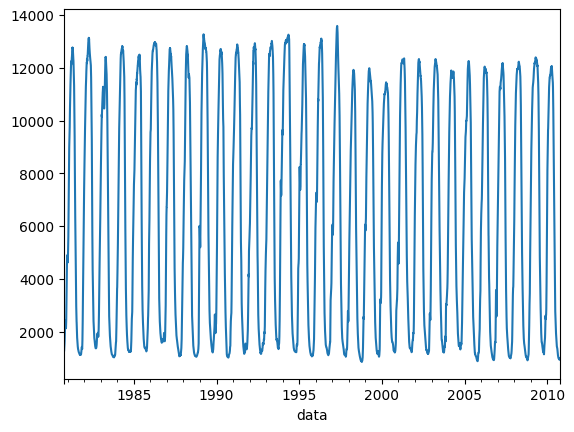

In [ ]:
df_streamflow['Streamflow'].plot()

<Axes: xlabel='data'>

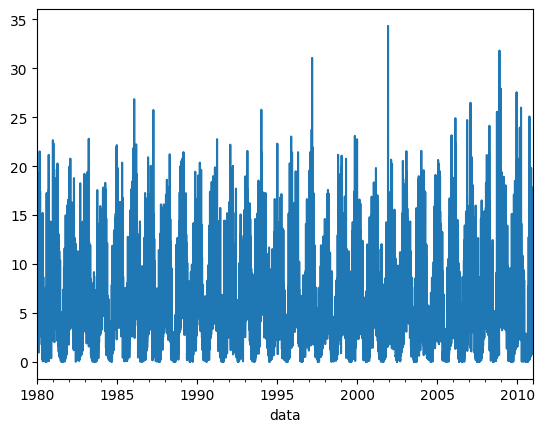

In [ ]:
df_climate['p_ens(mm)'].plot()

In [ ]:
Q = df_streamflow['Streamflow']['1980-10-1':'1980-12-31']
P = df_climate['p_ens(mm)']['1980-10-1':'1980-12-31']
index_prec = df_climate['1980-10-1':'1980-12-31'].index

In [ ]:
Q,P

(data
 1980-10-01    1165.80
 1980-10-02    1181.20
 1980-10-03    1194.40
 1980-10-04    1201.00
 1980-10-05    1203.20
                ...   
 1980-12-27    4855.16
 1980-12-28    4824.28
 1980-12-29    4801.12
 1980-12-30    4770.24
 1980-12-31    4739.36
 Name: Streamflow, Length: 92, dtype: float64,
 data
 1980-10-01     4.669
 1980-10-02    11.884
 1980-10-03     9.195
 1980-10-04     9.348
 1980-10-05    14.407
                ...  
 1980-12-27     7.793
 1980-12-28     7.064
 1980-12-29     8.746
 1980-12-30     5.007
 1980-12-31     3.811
 Name: p_ens(mm), Length: 92, dtype: float64)

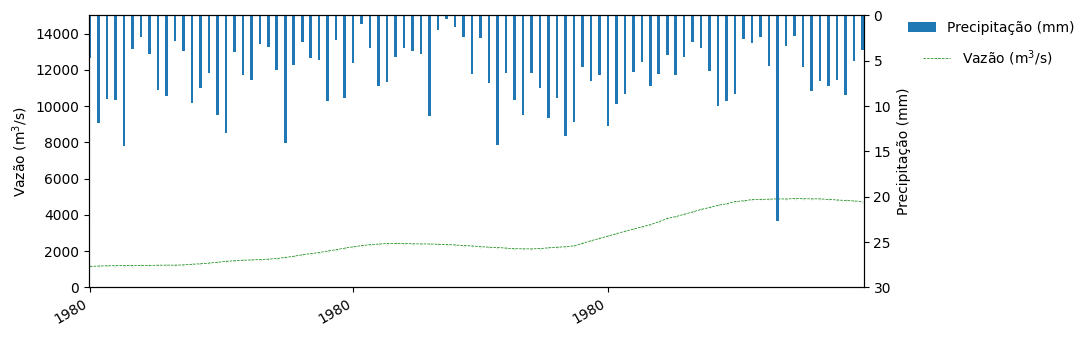

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(Q,color='green', marker='o', linestyle='dashed',linewidth=0.5, markersize=0.1, label = r'Vazão (m$^3$/s)')
ax1.set_ylim(0,15000)
ax1.margins(0.0)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gcf().autofmt_xdate()
ax1.set_ylabel(r'Vazão (m$^3$/s)', fontsize=10) #y label

ax1.legend(bbox_to_anchor=(1.25, 0.9), borderaxespad=0.,frameon=False)

ax2 = ax1.twinx()
ax2.margins(0.0)
ax2.bar(index_prec,P, width=0.3, label = 'Precipitação (mm)')

ax2.set_ylabel('Precipitação (mm)', fontsize=10) #y label
ax2.set_ylim(30,0)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.,frameon=False)
#plt.savefig('graficos/vazao_versus_prec_selecao.png', dpi = 300, bbox_inches='tight')
plt.show()

## Mudanças Climáticas?

In [ ]:
df_climate['t_med'] = (df_climate['tmin_ens']+df_climate['tmax_ens'])/2

<Axes: xlabel='data'>

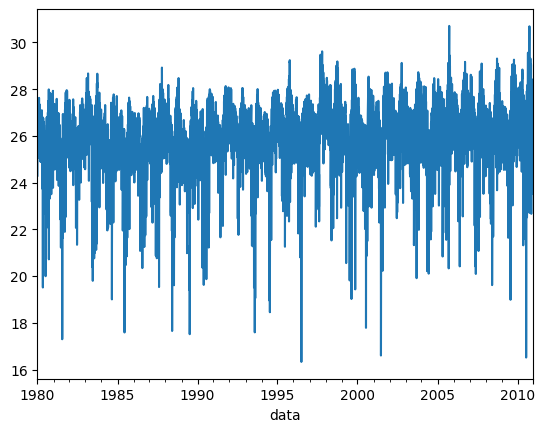

In [ ]:
df_climate['t_med'].plot()

In [ ]:
df_climate_selecao = df_climate[['p_ens(mm)','t_med']]

In [ ]:
df_climate_selecao

,p_ens(mm),t_med
data,,
1980-01-01,17.744,24.2970
1980-01-02,6.515,25.0930
1980-01-03,4.314,26.0475
1980-01-04,3.955,26.6925
1980-01-05,4.798,26.3105
...,...,...
2010-12-27,9.375,26.2540
2010-12-28,6.888,27.0510
2010-12-29,4.397,27.1995


In [ ]:
print(df_climate_selecao.dtypes)

p_ens(mm)    float64
t_med        float64
dtype: object


In [ ]:
df_climate_selecao['data'] = pd.to_datetime(df_climate_selecao.index)
df_climate_selecao_anual = df_climate_selecao.resample('YE', on='data').mean()

<ipython-input-37-96fbf198923f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_climate_selecao['data'] = pd.to_datetime(df_climate_selecao.index)


In [ ]:
df_climate_selecao_anual['ano'] = df_climate_selecao_anual.index.year
df_climate_selecao_anual

,p_ens(mm),t_med,ano
data,,,
1980-12-31,5.391336,25.876730,1980
1981-12-31,5.778463,25.726196,1981
1982-12-31,5.864907,25.866263,1982
1983-12-31,5.057241,26.150812,1983
1984-12-31,6.080784,25.587354,1984
1985-12-31,6.417627,25.381545,1985
1986-12-31,6.125422,25.486716,1986
1987-12-31,5.548186,25.993849,1987
1988-12-31,5.464046,25.670287,1988


# Regressão Linear dos dados de temperatura

In [ ]:
year = df_climate_selecao_anual['ano'].values
temp = df_climate_selecao_anual['t_med'].values

In [ ]:
a1, a0 = numpy.polyfit(year, temp,1)
f_linear = numpy.poly1d((a1, a0))

In [ ]:
a1, a0

(np.float64(0.029154240559705957), np.float64(-32.120196495916005))

O que acabamos de fazer foi usar o método dos mínimos quadrados para ajustar uma linha reta aos dados de temperatura em função do ano.

A equação que geramos foi:

$$
T_{\rm anual} = -32.1202 + 0.02915 \, \text{ano}
$$


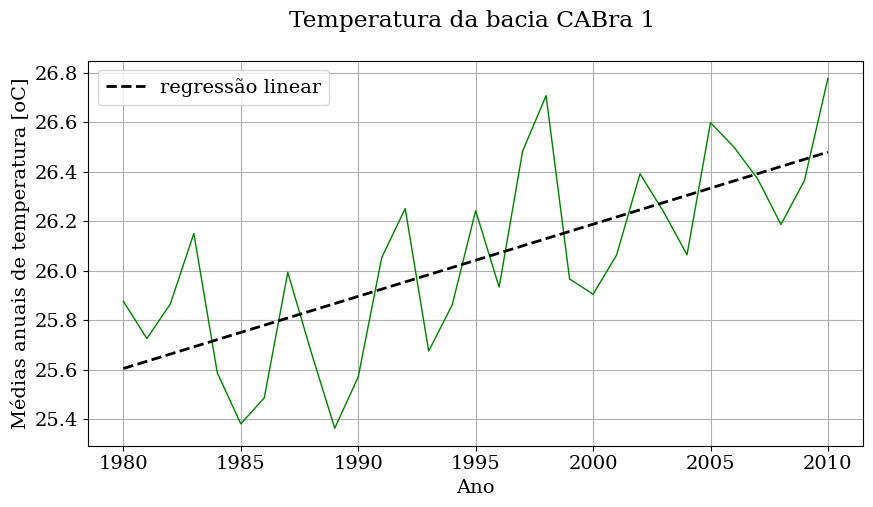

In [ ]:
plt.rc('font',family='serif',size='14')
plt.figure(figsize=(10,5))
plt.plot(year,temp,color='green',linestyle='-', linewidth=1)
plt.plot(year,f_linear(year),color='black',linestyle='--', linewidth=2,label='regressão linear')
plt.title('Temperatura da bacia CABra 1 \n')
plt.xlabel('Ano')
plt.ylabel('Médias anuais de temperatura [oC]')
plt.legend(loc='best',fontsize=14)
plt.grid();

In [ ]:
f_linear(2025)

np.float64(26.917140637488558)

In [ ]:
delta = f_linear(2010)-f_linear(1980)
delta

np.float64(0.8746272167911755)

In [ ]:
delta = f_linear(2025)-f_linear(1980)
delta

np.float64(1.3119408251867668)